# Converting between representations

*Prerequisite: [Distribution basics](01_distributions.ipynb). This
notebook assumes you're comfortable with the `SupportsX` protocol family
and the standard ops.*

Real probabilistic workflows move fluidly between representations of
the same random variable: sometimes you want a parametric density,
sometimes a cloud of samples, sometimes a KDE you can differentiate.
ProbPipe supports three complementary conversion mechanisms, each
appropriate in a different situation:

| Mechanism | When to use it | What it preserves |
|---|---|---|
| **Bijectors + `TransformedDistribution`** | You know the algebraic transform (e.g. `exp`, `sigmoid`) that moves you between spaces | Exact — the change-of-variables formula is applied automatically |
| **`from_distribution`** | You want to fit one parametric family to another | Moments (mean / variance / cov) |
| **Converter registry** | You need to satisfy a protocol the source distribution lacks (e.g. get `log_prob` from empirical samples) | Depends on the target — KDE for density, parametric for moments |

This notebook covers each in turn.

In [1]:
import jax
import jax.numpy as jnp
import numpy as np
import matplotlib.pyplot as plt
import tensorflow_probability.substrates.jax.bijectors as tfb

from probpipe import (
    Normal,
    Beta,
    Gamma,
    MultivariateNormal,
    RecordEmpiricalDistribution,
    TransformedDistribution,
    KDEDistribution,
    sample,
    log_prob,
    prob,
    mean,
    variance,
    from_distribution,
    converter_registry,
)
from probpipe.core.protocols import SupportsLogProb

key = jax.random.PRNGKey(0)
# This notebook is about conversion mechanics, not Prefect — disable orchestration
from probpipe import WorkflowKind, prefect_config
prefect_config.workflow_kind = WorkflowKind.OFF


## 1. Bijectors — algebraic transforms with automatic Jacobian

A **bijector** is an invertible, differentiable function. Given a base
distribution `X ~ p_X` and a bijector `f`, `TransformedDistribution(X, f)`
represents `Y = f(X)` with density

$$p_Y(y) = p_X(f^{-1}(y)) \cdot \left|\det \frac{\partial f^{-1}}{\partial y}\right|.$$

The change-of-variables Jacobian correction is applied automatically on
every `log_prob` call — you don't compute it by hand.

In [2]:
base = Normal(loc=0.0, scale=0.5, name="base")
log_normal = TransformedDistribution(base, tfb.Exp(), name="log_normal")
print(f"base support:        {base.support}")
print(f"log_normal support:  {log_normal.support}")

# Samples are just f applied to base samples
draws_base = jnp.asarray(sample(base, sample_shape=(5000,)))
draws_ln = jnp.asarray(sample(log_normal, sample_shape=(5000,)))
print(f'max(|exp(base) - log_normal|) = {float(jnp.max(jnp.abs(jnp.exp(draws_base) - draws_ln))):.2e}')

base support:        real
log_normal support:  positive


max(|exp(base) - log_normal|) = 6.07e+00


The log-density matches the analytical log-normal formula:

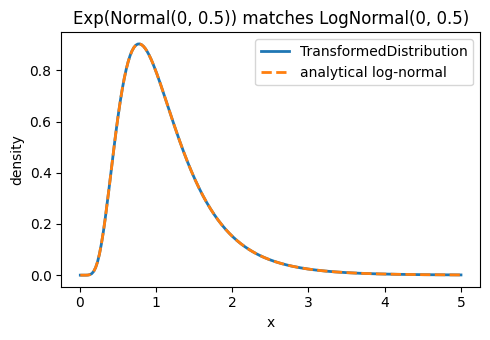

In [3]:
x = jnp.linspace(0.01, 5.0, 200)
import jax.scipy.stats as jstats
# NOTE: log_prob(td, v) inside jax.vmap raises UnexpectedTracerError —
# WorkflowFunction state escapes the trace scope (see issue #163).
# Bypass the WF layer and call the protocol method directly.
lp_td = jax.vmap(lambda v: log_normal._log_prob(v))(x)
lp_ref = jstats.norm.logpdf(jnp.log(x), 0.0, 0.5) - jnp.log(x)

fig, ax = plt.subplots(figsize=(5, 3.5))
ax.plot(x, jnp.exp(lp_td), label="TransformedDistribution", linewidth=2)
ax.plot(x, jnp.exp(lp_ref), "--", label="analytical log-normal", linewidth=2)
ax.set_xlabel("x"); ax.set_ylabel("density"); ax.legend()
ax.set_title("Exp(Normal(0, 0.5)) matches LogNormal(0, 0.5)")
plt.tight_layout(); plt.show()

### Common bijectors

| Bijector | Mapping | Typical use |
|---|---|---|
| `tfb.Exp()` | ℝ → (0, ∞) | Positive parameters (rates, variances) |
| `tfb.Log()` | (0, ∞) → ℝ | Inverse of `Exp` |
| `tfb.Sigmoid()` | ℝ → (0, 1) | Probabilities |
| `tfb.Softplus()` | ℝ → (0, ∞) | Smooth positive constraint |
| `tfb.Shift(c)` | `x → x + c` | Location shift |
| `tfb.Scale(s)` | `x → s · x` | Scale |
| `tfb.Chain([...])` | Composition | Combine bijectors |

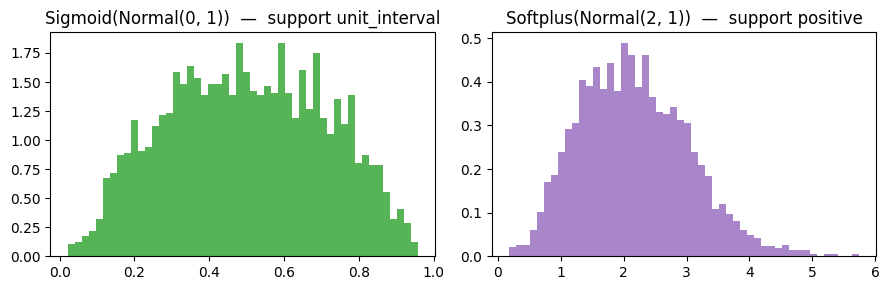

In [4]:
# Sigmoid gives a unit-interval distribution; Softplus gives a smooth
# positive one. Each side-by-side with its base.
bounded = TransformedDistribution(Normal(loc=0.0, scale=1.0, name='base_b'), tfb.Sigmoid(), name='bounded')
positive = TransformedDistribution(Normal(loc=2.0, scale=1.0, name='base_p'), tfb.Softplus(), name='positive')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(9, 3))
ax1.hist(np.asarray(sample(bounded, sample_shape=(3000,))),
         bins=50, density=True, alpha=0.8, color="tab:green")
ax1.set_title(f"Sigmoid(Normal(0, 1))  —  support {bounded.support}")

ax2.hist(np.asarray(sample(positive, sample_shape=(3000,))),
         bins=50, density=True, alpha=0.8, color="tab:purple")
ax2.set_title(f"Softplus(Normal(2, 1))  —  support {positive.support}")
plt.tight_layout(); plt.show()

### Chaining

`tfb.Chain([f1, f2, f3])` composes bijectors. The list is applied in
reverse order — the **last** element of the list is applied **first**
(matching the convention for composing functions). So
`Chain([Exp, Shift(1), Scale(2)])` means: scale by 2, then shift by 1,
then exponentiate.

support: positive,  min sample: 0.003 (should be > 0)


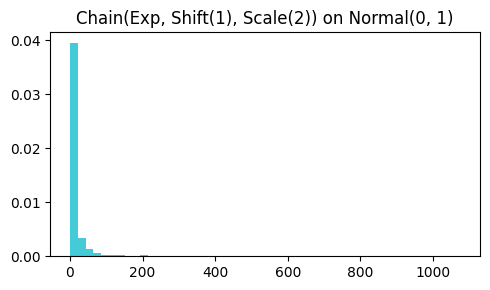

In [5]:
chain = tfb.Chain([tfb.Exp(), tfb.Shift(1.0), tfb.Scale(2.0)])
td = TransformedDistribution(Normal(loc=0.0, scale=1.0, name='base'), chain, name='chained')
draws = jnp.asarray(sample(td, sample_shape=(3000,)))
print(f"support: {td.support},  min sample: {float(jnp.min(draws)):.3f} (should be > 0)")
fig, ax = plt.subplots(figsize=(5, 3))
ax.hist(np.asarray(draws), bins=50, density=True, alpha=0.8, color="tab:cyan")
ax.set_title("Chain(Exp, Shift(1), Scale(2)) on Normal(0, 1)")
plt.tight_layout(); plt.show()

### Bijectors on empirical distributions

`TransformedDistribution` doesn't require a TFP base — it works on any
`SupportsSampling` distribution. When the base is empirical, sampling
is "resample the stored points, then apply the bijector"; `log_prob`
uses the base's density (an internal Gaussian KDE for empirical) and
adds the Jacobian term.

In [6]:
raw = jax.random.normal(jax.random.PRNGKey(5), (500,))
emp = RecordEmpiricalDistribution(raw, name="normal_samples")
emp_exp = TransformedDistribution(emp, tfb.Exp(), name="exp_normal_samples")
print(f"base  event_shape:        {emp.event_shape}")
print(f"transformed event_shape:  {emp_exp.event_shape}")
print(f"transformed support:      {emp_exp.support}")

draws = jnp.asarray(sample(emp_exp, sample_shape=(1000,)))
print(f"all positive: {bool(jnp.all(draws > 0))}")

base  event_shape:        ()
transformed event_shape:  ()
transformed support:      positive


all positive: True


## 2. `from_distribution` — moment-matching between families

`from_distribution(source, target_type)` fits the `target_type`
parametric family to the source by extracting moments. When the source
has analytical moments, the extraction is exact; otherwise it uses
Monte Carlo. Support compatibility is checked by default — for example,
you can't fit a `Beta` (unit interval) to a `Normal` (real line) unless
you pass `check_support=False`.

In [7]:
# Gamma (positive) → Normal (real) is allowed: positive ⊂ real.
g = Gamma(concentration=9.0, rate=1.0, name="g")  # mean=9, var=9
n_fit = from_distribution(g, Normal, name="n_fit")
print(f"source Gamma: mean={float(mean(g)):.3f}, var={float(variance(g)):.3f}")
print(f"fitted Normal: loc={float(n_fit.loc):.3f}, scale={float(n_fit.scale):.3f}")

source Gamma: mean=9.000, var=9.000
fitted Normal: loc=9.000, scale=3.000


### When the support check blocks a fit

Fitting a `Beta` to a `Normal` is refused by default because a Normal
can produce values outside [0, 1]. When you know the fit is meaningful
anyway (e.g. the base is truncated or concentrated safely inside the
target support), override with `check_support=False`.

In [8]:
n = Normal(loc=0.5, scale=0.1, name="n")
try:
    from_distribution(n, Beta)
except ValueError as e:
    print(f"refused: {e}")

b_fit = from_distribution(n, Beta, check_support=False,
                          key=jax.random.PRNGKey(7), num_samples=5000,
                          name="b_fit")
print(f"\nwith check_support=False:")
print(f"  Beta fit alpha={float(b_fit.alpha):.3f}, beta={float(b_fit.beta):.3f}")

refused: Cannot convert Normal (support=real) to Beta (support=unit_interval). Pass check_support=False to override.

with check_support=False:
  Beta fit alpha=12.000, beta=12.000


### Empirical → parametric

`from_distribution` on an empirical source draws its samples and fits
the target family to the sample moments. Useful when you want a
compact parametric summary of MCMC output.

In [9]:
raw_beta = jax.random.beta(jax.random.PRNGKey(8), 2.0, 5.0, shape=(500,))
emp_prop = RecordEmpiricalDistribution(raw_beta, name="mcmc_proportions")
b_fit2 = from_distribution(emp_prop, Beta, check_support=False, name="b_fit2")
print(f"fitted Beta to MCMC samples:")
print(f"  alpha={float(b_fit2.alpha):.3f}, beta={float(b_fit2.beta):.3f}")
print(f"  true  alpha=2.0,      beta=5.0  (the samples were drawn from Beta(2, 5))")

fitted Beta to MCMC samples:
  alpha=1.789, beta=4.527
  true  alpha=2.0,      beta=5.0  (the samples were drawn from Beta(2, 5))


## 3. The converter registry — bridging protocols

When a distribution lacks a capability you need, you don't always want
to pick the target family by hand. The **converter registry** handles
the most common request: "make this satisfy `SupportsLogProb`" (i.e.,
give me a density I can evaluate). For `RecordEmpiricalDistribution`
the default answer is `KDEDistribution` — nonparametric, no assumptions.

In [10]:
emp = RecordEmpiricalDistribution(jax.random.normal(jax.random.PRNGKey(9), (500,)), name='mcmc_posterior')
print(f"source supports log_prob? {isinstance(emp, SupportsLogProb)}")
converted = converter_registry.convert(emp, SupportsLogProb)
print(f"converted: {converted}  ({type(converted).__name__})")
print(f"log_prob(converted, 0.0) = {float(log_prob(converted, 0.0)):.4f}")

source supports log_prob? False
converted: KDEDistribution(n=500, event_shape=())  (KDEDistribution)


log_prob(converted, 0.0) = -1.0016


When the source already satisfies the protocol, the registry returns
the original object unchanged:

In [11]:
n = Normal(loc=2.0, scale=0.5, name="n")
print(f"n is converted back to itself: {converter_registry.convert(n, SupportsLogProb) is n}")

n is converted back to itself: True


### Inspecting a conversion without running it

`converter_registry.check` returns a `ConversionInfo` that describes
what would happen — useful for introspection or debugging.

In [12]:
info = converter_registry.check(emp, SupportsLogProb)
print(f"method:       {info.method}")
print(f"description:  {info.description!r}")
print(f"feasible:     {info.feasible}")

method:       ConversionMethod.MOMENT_MATCH
description:  'Moment-match RecordEmpiricalDistribution -> KDEDistribution'
feasible:     True


### KDE vs parametric — picking the right conversion

The registry's default is KDE because it doesn't assume anything about
the shape of the distribution. When you *do* know something — "these
samples live on [0, 1]" — a parametric fit via `from_distribution` is
usually tighter. Compare the two on the same Beta-shaped data:

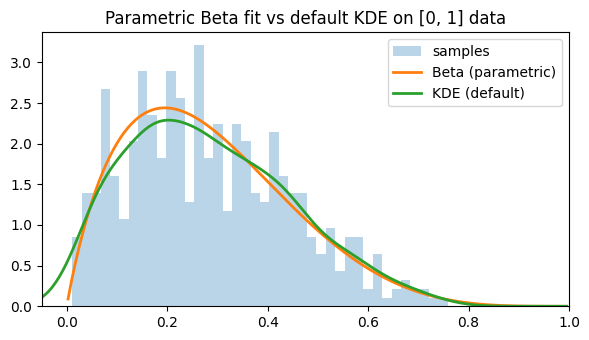

In [13]:
raw_beta2 = jax.random.beta(jax.random.PRNGKey(10), 2.0, 5.0, shape=(500,))
emp_beta = RecordEmpiricalDistribution(raw_beta2, name="mcmc_beta")

kde_fit = converter_registry.convert(emp_beta, SupportsLogProb)         # nonparametric
beta_fit = from_distribution(emp_beta, Beta, check_support=False,
                              name="beta_fit")                           # parametric

x = jnp.linspace(-0.05, 0.995, 300)
fig, ax = plt.subplots(figsize=(6, 3.5))
ax.hist(np.asarray(raw_beta2), bins=40, density=True, alpha=0.3, label='samples')
ax.plot(x, np.asarray(prob(beta_fit, x)), label="Beta (parametric)", linewidth=2)
ax.plot(x, np.asarray(prob(kde_fit, x)), label="KDE (default)", linewidth=2)
ax.set_xlim(-0.05, 1.0); ax.legend()
ax.set_title("Parametric Beta fit vs default KDE on [0, 1] data")
plt.tight_layout(); plt.show()

## 4. Summary

Three complementary conversion mechanisms, each right in a different
situation:

- **`TransformedDistribution(base, bijector)`** — when the transform is
  known algebraically. The Jacobian correction is exact and runs
  automatically.
- **`from_distribution(source, target_type)`** — when you want a
  parametric family fitted by moment matching. Support compatibility
  is checked by default; override with `check_support=False` when you
  know the fit is meaningful.
- **`converter_registry.convert(source, Protocol)`** — when you need to
  satisfy a capability (typically `SupportsLogProb`) and don't care
  about the specific target family. KDE is the default for
  log-prob conversions; inspect via `.check()` before running if you
  want to know what the registry will pick.